# Ventana Computacional VIII.1  
## Embedding de Carleman con excitación periódica

Este notebook acompaña el **Capítulo VIII: Embeddings de Carleman** de la monografía.

El objetivo es estudiar un sistema escalar no lineal con excitación externa periódica:

$$
\dot{x}=ax+bx^2+c\,u(t)x,
\qquad
u(t)=A\cos(\omega t).
$$

El término $bx^2$ introduce la no linealidad polinomial. El término $c\,u(t)x$ representa una excitación externa multiplicativa. Al aplicar el embedding de Carleman con

$$
z_k=x^k,
$$

se obtiene la jerarquía

$$
\dot z_k
=
ka z_k + kb z_{k+1} + kc\,u(t)z_k.
$$

En forma matricial:

$$
\dot z = \left(\mathcal K_0 + u(t)\mathcal K_1\right)z.
$$

Después de truncar en orden $N$, el sistema liftado se convierte en un sistema lineal periódico de dimensión finita. Esta es la zona de contacto entre **Carleman**, **Floquet** y el análisis de sistemas forzados.

## 1. Instalación e importación de librerías

En Google Colab, `numpy`, `scipy` y `matplotlib` normalmente ya están disponibles. Esta celda solo importa las librerías necesarias.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.linalg import eigvals

## 2. Definición del sistema no lineal forzado

Trabajaremos con

$$
\dot{x}=\bigl(a+c u(t)\bigr)x+bx^2,
\qquad
u(t)=A\cos(\omega t).
$$

Los parámetros se escogen para que la trayectoria sea estable y la comparación con truncaciones de Carleman sea visible durante varios periodos.

In [2]:
# Parámetros del sistema
# Puedes modificar estos valores para explorar otros regímenes.
a = -1.0
b = 1.0
c = 0.8
A = 0.7
omega = 2*np.pi   # periodo T_u = 1

x0 = 0.15         # condición inicial
T_final = 8.0     # horizonte de simulación
t_eval = np.linspace(0, T_final, 2500)


def u(t):
    """Excitación periódica externa."""
    return A*np.cos(omega*t)


def rhs_nonlinear(t, x):
    """Sistema no lineal original."""
    return [(a + c*u(t))*x[0] + b*x[0]**2]

## 3. Solución directa del sistema no lineal

Esta solución será nuestra referencia para evaluar las aproximaciones de Carleman truncadas.

In [3]:
sol_original = solve_ivp(
    rhs_nonlinear,
    (t_eval[0], t_eval[-1]),
    [x0],
    t_eval=t_eval,
    rtol=1e-10,
    atol=1e-12
)

x_true = sol_original.y[0]

print("Integración del sistema original completada.")
print(f"x(0) = {x0:.4f}")
print(f"x(T_final) = {x_true[-1]:.6f}")

Integración del sistema original completada.
x(0) = 0.1500
x(T_final) = 0.000059


## 4. Construcción de las matrices de Carleman truncadas

Para el sistema

$$
\dot{x}=ax+bx^2+c\,u(t)x,
$$

la jerarquía de Carleman satisface

$$
\dot z_k = ka z_k + kbz_{k+1} + kc\,u(t)z_k.
$$

Al truncar en orden $N$, definimos

$$
z^{(N)}=(z_1,z_2,\ldots,z_N)^T.
$$

La matriz autónoma $\mathcal K_{0,N}$ contiene la diagonal $ka$ y la superdiagonal $kb$. La matriz $\mathcal K_{1,N}$ contiene la modulación externa $kc$ en la diagonal.

In [4]:
def carleman_matrices(a, b, c, N):
    """Construye K0 y K1 para el embedding de Carleman truncado."""
    K0 = np.zeros((N, N))
    K1 = np.zeros((N, N))

    for k in range(1, N+1):
        K0[k-1, k-1] = k*a
        K1[k-1, k-1] = k*c
        if k < N:
            K0[k-1, k] = k*b

    return K0, K1


def lifted_initial_condition(x0, N):
    """Condición inicial liftada: z_k(0)=x0^k."""
    return np.array([x0**k for k in range(1, N+1)])


def solve_carleman(a, b, c, x0, N, t_eval):
    """Integra el sistema de Carleman truncado y devuelve z_1(t)."""
    K0, K1 = carleman_matrices(a, b, c, N)
    z0 = lifted_initial_condition(x0, N)

    def rhs(t, z):
        return (K0 + u(t)*K1) @ z

    sol = solve_ivp(
        rhs,
        (t_eval[0], t_eval[-1]),
        z0,
        t_eval=t_eval,
        rtol=1e-10,
        atol=1e-12
    )
    return sol.y[0]

## 5. Gráfica de la excitación periódica

Antes de comparar soluciones, conviene mirar la fuente externa que modula al sistema.

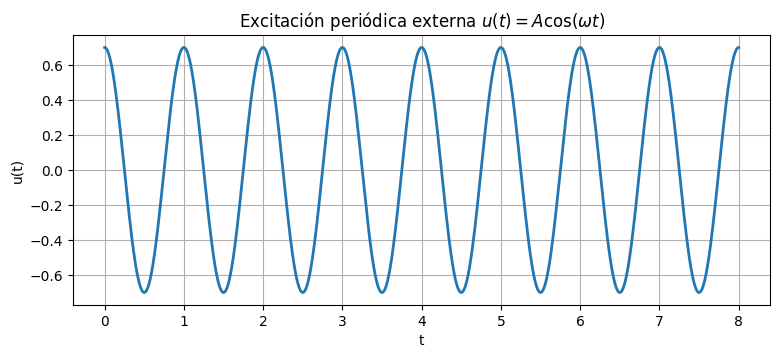

In [5]:
plt.figure(figsize=(9, 3.5))
plt.plot(t_eval, u(t_eval), linewidth=2)
plt.xlabel("t")
plt.ylabel("u(t)")
plt.title(r"Excitación periódica externa $u(t)=A\cos(\omega t)$")
plt.grid(True)
plt.show()

## 6. Comparación: solución no lineal vs. truncaciones de Carleman

Comparamos la solución original $x(t)$ con la primera componente $z_1(t)$ de truncaciones de orden $N=1,2,4,8$.

El caso $N=1$ corresponde a retener solamente el estado original y descartar la cascada no lineal. Órdenes mayores incorporan progresivamente monomios de grado superior.

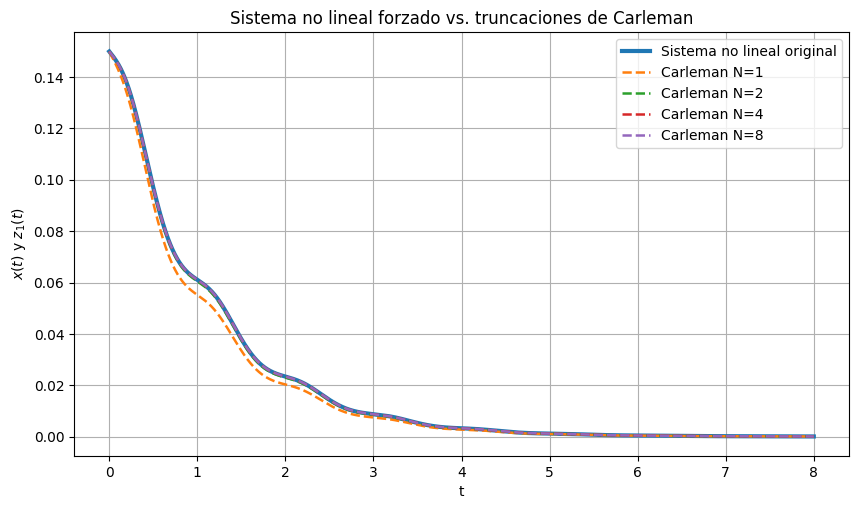

In [6]:
orders = [1, 2, 4, 8]
carleman_solutions = {
    N: solve_carleman(a, b, c, x0, N, t_eval)
    for N in orders
}

plt.figure(figsize=(10, 5.5))
plt.plot(t_eval, x_true, linewidth=3, label="Sistema no lineal original")

for N in orders:
    plt.plot(t_eval, carleman_solutions[N], linestyle="--", linewidth=1.8, label=f"Carleman N={N}")

plt.xlabel("t")
plt.ylabel(r"$x(t)$ y $z_1(t)$")
plt.title("Sistema no lineal forzado vs. truncaciones de Carleman")
plt.legend()
plt.grid(True)
plt.show()

## 7. Error temporal por orden de truncación

Calculamos

$$
e_N(t)=|x(t)-z_1^{(N)}(t)|.
$$

Esta gráfica muestra que Carleman no produce una única aproximación, sino una jerarquía de aproximaciones lineales enriquecidas.

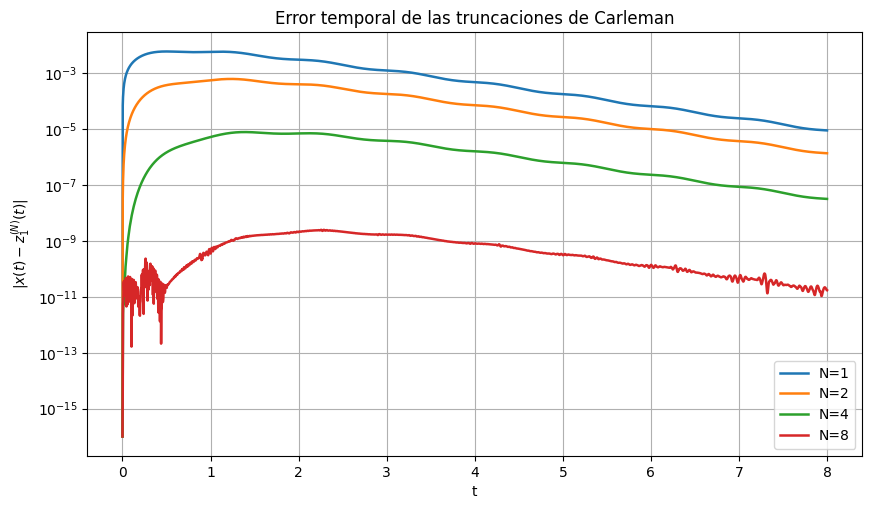

In [7]:
plt.figure(figsize=(10, 5.5))

for N in orders:
    error = np.abs(x_true - carleman_solutions[N])
    plt.semilogy(t_eval, error + 1e-16, linewidth=1.8, label=f"N={N}")

plt.xlabel("t")
plt.ylabel(r"$|x(t)-z_1^{(N)}(t)|$")
plt.title("Error temporal de las truncaciones de Carleman")
plt.legend()
plt.grid(True, which="both")
plt.show()

## 8. Error máximo contra orden de truncación

Ahora calculamos

$$
E_N=\max_{t\in[0,T]} |x(t)-z_1^{(N)}(t)|.
$$

Esta gráfica responde directamente a la crítica de dimensionalidad: sí, el orden aumenta la dimensión, pero también aumenta la riqueza de la representación dentro del régimen donde la truncación es válida.

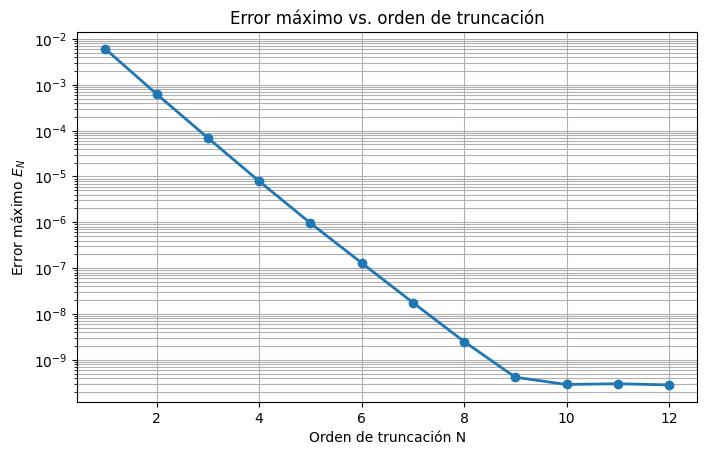

N= 1  error máximo = 6.063e-03
N= 2  error máximo = 6.296e-04
N= 3  error máximo = 6.947e-05
N= 4  error máximo = 7.897e-06
N= 5  error máximo = 9.623e-07
N= 6  error máximo = 1.302e-07
N= 7  error máximo = 1.774e-08
N= 8  error máximo = 2.499e-09
N= 9  error máximo = 4.152e-10
N=10  error máximo = 2.884e-10
N=11  error máximo = 2.996e-10
N=12  error máximo = 2.822e-10


In [8]:
all_orders = list(range(1, 13))
max_errors = []

for N in all_orders:
    z1 = solve_carleman(a, b, c, x0, N, t_eval)
    max_errors.append(np.max(np.abs(x_true - z1)))

plt.figure(figsize=(8, 4.8))
plt.semilogy(all_orders, max_errors, marker="o", linewidth=2)
plt.xlabel("Orden de truncación N")
plt.ylabel(r"Error máximo $E_N$")
plt.title("Error máximo vs. orden de truncación")
plt.grid(True, which="both")
plt.show()

for N, err in zip(all_orders, max_errors):
    print(f"N={N:2d}  error máximo = {err:.3e}")

## 9. Coeficientes periódicos en la matriz liftada

El sistema truncado tiene la forma

$$
\dot z^{(N)} = \bigl(\mathcal K_{0,N}+u(t)\mathcal K_{1,N}\bigr)z^{(N)}.
$$

Por tanto, los coeficientes diagonales efectivos son

$$
k(a+c u(t)),\qquad k=1,2,3,\ldots
$$

Esta gráfica hace visible la conexión con Floquet: después del lifting de Carleman, el sistema truncado es lineal periódico en el espacio ampliado.

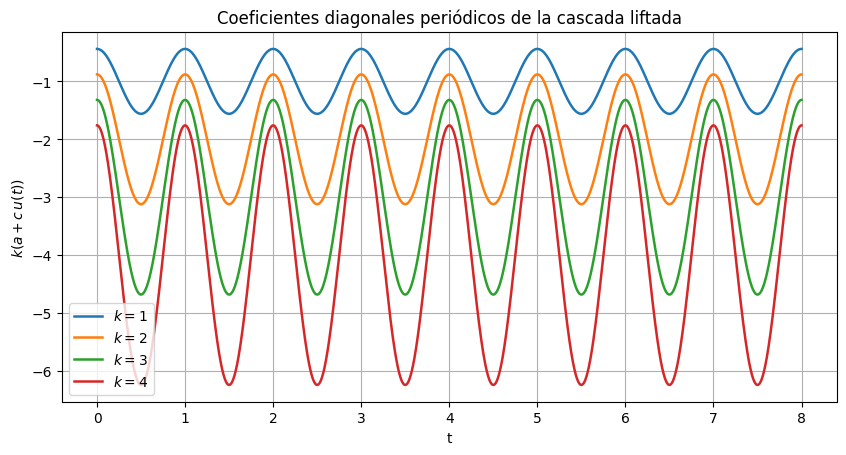

In [9]:
plt.figure(figsize=(10, 4.8))

for k in [1, 2, 3, 4]:
    coeff = k*(a + c*u(t_eval))
    plt.plot(t_eval, coeff, linewidth=1.8, label=fr"$k={k}$")

plt.xlabel("t")
plt.ylabel(r"$k(a+c\,u(t))$")
plt.title("Coeficientes diagonales periódicos de la cascada liftada")
plt.legend()
plt.grid(True)
plt.show()

## 10. Sensibilidad a la amplitud inicial

La calidad de una truncación de Carleman depende del régimen. Para amplitudes pequeñas, los monomios de orden alto suelen ser menos relevantes. Para amplitudes mayores, esos términos pueden crecer y la truncación pierde precisión.

Aquí fijamos un orden $N$ y variamos $x(0)$.

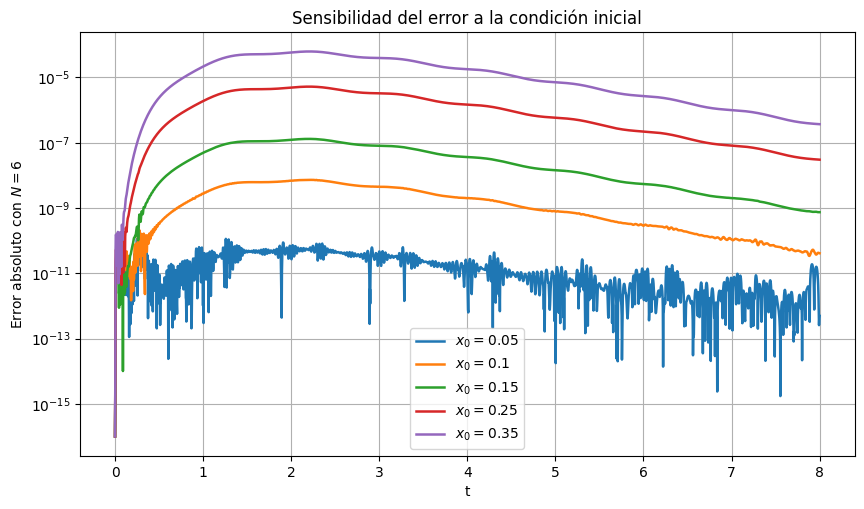

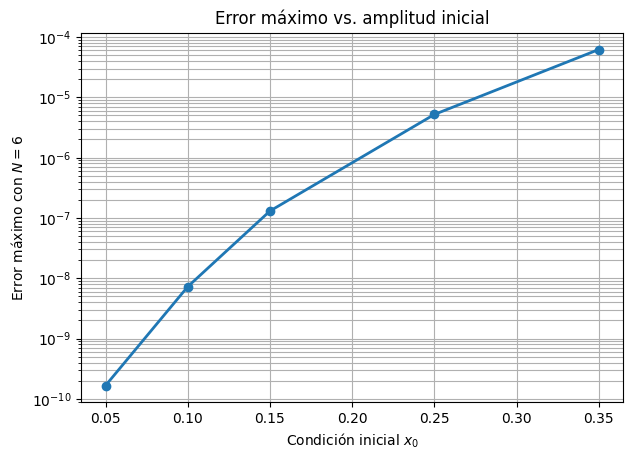

In [10]:
N_fixed = 6
x0_values = [0.05, 0.10, 0.15, 0.25, 0.35]
max_errors_x0 = []

plt.figure(figsize=(10, 5.5))

for x0_test in x0_values:
    sol = solve_ivp(
        rhs_nonlinear,
        (t_eval[0], t_eval[-1]),
        [x0_test],
        t_eval=t_eval,
        rtol=1e-10,
        atol=1e-12
    )
    x_ref = sol.y[0]
    z1 = solve_carleman(a, b, c, x0_test, N_fixed, t_eval)
    err = np.abs(x_ref - z1)
    max_errors_x0.append(np.max(err))
    plt.semilogy(t_eval, err + 1e-16, linewidth=1.8, label=fr"$x_0={x0_test}$")

plt.xlabel("t")
plt.ylabel(r"Error absoluto con $N=6$")
plt.title("Sensibilidad del error a la condición inicial")
plt.legend()
plt.grid(True, which="both")
plt.show()

plt.figure(figsize=(7, 4.8))
plt.semilogy(x0_values, max_errors_x0, marker="o", linewidth=2)
plt.xlabel(r"Condición inicial $x_0$")
plt.ylabel(r"Error máximo con $N=6$")
plt.title("Error máximo vs. amplitud inicial")
plt.grid(True, which="both")
plt.show()

## 11. Lectura opcional tipo Floquet: matriz monodromía truncada

Para una truncación fija $N$, el sistema liftado es lineal periódico:

$$
\dot z = \mathcal K(t)z,
\qquad
\mathcal K(t+T_u)=\mathcal K(t).
$$

Podemos aproximar la matriz de monodromía integrando la matriz fundamental durante un periodo de la excitación. Sus eigenvalores son multiplicadores de Floquet del sistema truncado.

Esto no reemplaza el análisis no lineal original, pero muestra cómo Carleman puede producir un objeto compatible con Floquet después del lifting.

Multiplicadores de Floquet aproximados para N=6:
mu_1 = 0.367879+0j, |mu_1| = 0.367879
mu_2 = 0.135335+0j, |mu_2| = 0.135335
mu_3 = 0.0497871+0j, |mu_3| = 0.0497871
mu_4 = 0.0183156+0j, |mu_4| = 0.0183156
mu_5 = 0.00673795+0j, |mu_5| = 0.00673795
mu_6 = 0.00247875+0j, |mu_6| = 0.00247875


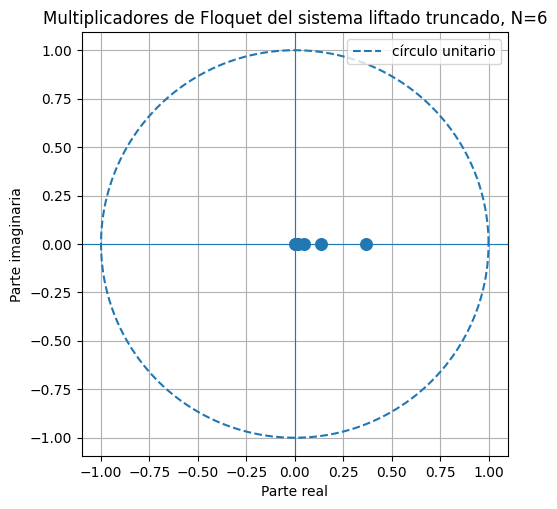

In [11]:
def monodromy_matrix(N, period=1.0):
    K0, K1 = carleman_matrices(a, b, c, N)
    Phi0 = np.eye(N).reshape(-1)

    def rhs_phi(t, phi_flat):
        Phi = phi_flat.reshape(N, N)
        Kt = K0 + u(t)*K1
        return (Kt @ Phi).reshape(-1)

    sol = solve_ivp(
        rhs_phi,
        (0, period),
        Phi0,
        t_eval=[period],
        rtol=1e-10,
        atol=1e-12
    )
    return sol.y[:, -1].reshape(N, N)

N_floquet = 6
Phi_T = monodromy_matrix(N_floquet, period=2*np.pi/omega)
mu = eigvals(Phi_T)

print(f"Multiplicadores de Floquet aproximados para N={N_floquet}:")
for j, val in enumerate(mu, start=1):
    print(f"mu_{j} = {val:.6g}, |mu_{j}| = {abs(val):.6g}")

plt.figure(figsize=(5.5, 5.5))
plt.scatter(mu.real, mu.imag, s=70)
theta = np.linspace(0, 2*np.pi, 400)
plt.plot(np.cos(theta), np.sin(theta), linestyle="--", label="círculo unitario")
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.xlabel("Parte real")
plt.ylabel("Parte imaginaria")
plt.title(f"Multiplicadores de Floquet del sistema liftado truncado, N={N_floquet}")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.show()

## 12. Conclusión conceptual

Este experimento muestra que una excitación periódica no impide usar Carleman; más bien revela una estructura más rica.

La no linealidad polinomial se organiza como una cascada de grados monomiales, mientras que la entrada periódica aparece como una modulación temporal de la matriz liftada:

$$
\dot z^{(N)}=\bigl(\mathcal K_{0,N}+u(t)\mathcal K_{1,N}\bigr)z^{(N)}.
$$

Así, un sistema no lineal forzado se transforma, tras truncación, en un sistema lineal periódico en un espacio ampliado.

La dimensión crece, desde luego. Pero esa dimensión no es arbitraria: cada coordenada adicional representa un grado monomial de la no linealidad. En ese sentido, Carleman no evita la dificultad de los sistemas no lineales; la reorganiza en una jerarquía computable, truncable y visualizable.